In [77]:
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from SeqModCNN import *
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import sys

from one_hot_encode import one_hot_encode_sequence_list

sys.path.append("../")
from trainers import seqCNN_trainer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


* Generate data from a simple mathematical equation.

$$
\text{score}_b =
\sum_{i=1}^{W}
\Big(
\sin(2.5\,X_{b,0,i}) \cdot \cos(X_{b,1,i})
+ \tfrac{1}{2}X_{b,2,i}^{3}
- e^{-X_{b,3,i}^{2}}
\Big)
$$

In [78]:
import torch

# Dimensions
B = 100   # batch size
C = 4      # channels
W = 500    # width

# Random input
X = torch.randn(B, C, W)

# Nonlinear score
score = (
    torch.sin(2.5 * X[:, 0, :]) * torch.cos(X[:, 1, :])
    + 0.5 * X[:, 2, :] ** 3
    - torch.exp(-X[:, 3, :] ** 2)
).sum(dim=1)

# Binary labels
y = (score > 0).long()

print(X.shape) 
print(y.shape) 

torch.Size([100, 4, 500])
torch.Size([100])


* Build a function to generate random sequences

In [79]:
import random
def generate_random_sequences(number, length, vocab = ['A', 'T', 'G', 'C']):
	return [''.join(random.choices(k = length, population=vocab)) for i in range(number)]

* Build a function to add a specific motif to a random position of the samples of class 1.


In [80]:
def integrate_motif(motif, targets, sequences):
	import random
	seq_len = len(sequences[0])
	effective_sequence_length = seq_len - len(motif)
	
	positions_to_place = [random.randint(1, effective_sequence_length) for x in range(len(sequences))]
	for i in range(len(sequences)):
        
		if targets[i] == 1:
			sequences[i][positions_to_place[i]:positions_to_place[i]+len(motif)] = motif

	return(sequences)
    
    

* Build the sequence data.

In [81]:
# Define sequence length and number.
seq_W = 100
seq_C = 4
sequence_vocab = ['A', 'T', 'G', 'C']

# Generate a list of random sequences.
random_sequence_list = generate_random_sequences(number = B, length = seq_W, vocab=sequence_vocab)

# Integrate a sequence motif in all the samples of class 1.
sequence_list = integrate_motif(motif = 'ATGGGTGA', targets = y, sequences=random_sequence_list)

# One hot encode sequences.
seq_X = one_hot_encode_sequence_list(random_sequence_list)

* Split the data to train and test.
* Train the model.


In [82]:
# Note
# Regression tasks cannot be run with return_probs = True
#When residual blocks are used stride should be 1

# Define model parameters.
data_tensor = X
seq_data_tensor = seq_X
targets = y.unsqueeze(1)
batch_size = 20
n_epochs = 100
mode = 'classify'


if mode == 'regress':
	return_probs = False
else: 
	return_probs = True

# Define convolution fparameters
conv_params = [5,1,1]
seq_conv_params = [3,1,1]

#Split to traning and test sets.
# Create indices
indices = np.arange(X.shape[0])

# Split indices
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# Split data
X_train, seq_X_train, y_train = X[train_idx], seq_X[train_idx], targets[train_idx]
X_test, seq_X_test, y_test = X[train_idx], seq_X[train_idx], targets[train_idx]


#Convert to torch datasets
train_dataset = TensorDataset(X_train, seq_X_train, y_train)
test_dataset = TensorDataset(X_test, seq_X_test, y_test)

# Split datasets to batches and convert datasets to data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# # First run the model for the multichannel_tensor
# simple_cnn = simple_multi_dimensional_cnn(input_len = data_tensor.shape[2],
# 									channels=data_tensor.shape[1],
# 									hist_param_list=[3,1,1],
#                                     return_embedding=True)

# Define the model.
seq_model = seqCNN(input_len = W, channels = C, hist_param_list = conv_params,
        seq_param_list = seq_conv_params, seq_len = seq_W, seq_channels = seq_C,
          return_embedding = True)

#Define the trainer.
simple_cnn_trainer = seqCNN_trainer(model=seq_model,
							lr=1e-6,epochs = n_epochs,
							train_loader=train_loader, test_loader=test_loader, mode=mode,
                            stopper_delta=0.0001, return_probs=return_probs, use_early_stopping=False)


#Train the model on the train set.
result = simple_cnn_trainer.train() 


#Exapand the result to distinct variabbles.
if mode == 'classify':
	cnn_test_acc, epoch_mean_batch_acc, losses, epoch_mean_test_losses, trained_model, total_predictions, total_test_labels, probs, xembed = result
elif mode == 'regress':
	cnn_test_acc, epoch_mean_batch_acc, losses, epoch_mean_test_losses, trained_model, total_predictions, total_test_labels, xembed = result


After the convolutiopn block x has length 61
After the convolutiopn block sequence has length 12
Dim after concatenation 2336


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:02<00:00, 40.89it/s]


* Plot model's performance

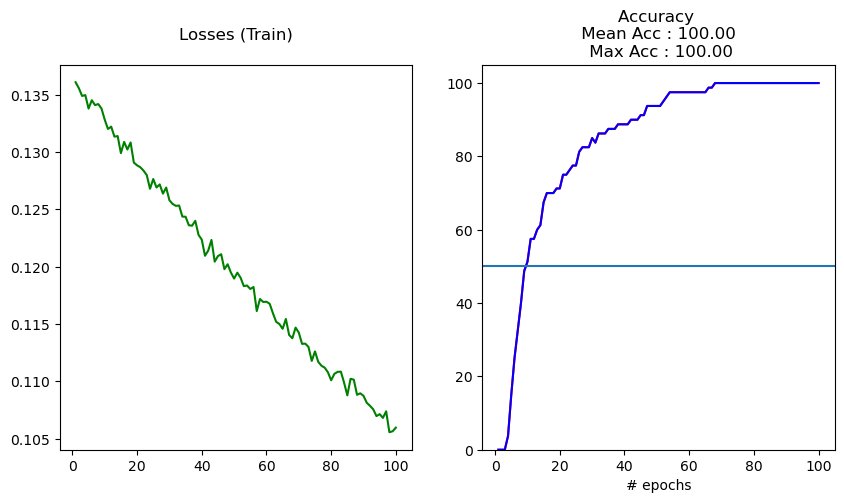

In [83]:

# Plot the loss and the accuracy of the model


fig, axes = plt.subplots(nrows=1, ncols=2, figsize = (10,5))
ax1, ax2 = axes.flatten()
ax1.set_title('Losses (Train)\n')
ax1.plot(list(range(1,len(losses) + 1)),losses, c = 'green',
             linestyle='-')
# ax1.scatter(x = list(range(1,n_epochs + 1)),y = loss, c = 'green')

mean_acc = f"{(np.mean(cnn_test_acc[-2:]).item()):.2f}"
max_acc = f"{(np.max(cnn_test_acc).item()):.2f}"

if mode == 'classify':
	ax2.set_title(f'Accuracy \n Mean Acc : {mean_acc} \n Max Acc : {max_acc}')
	ax2.set_ylim((0,105))
	ax2.set_xlabel('# epochs')
	ax2.plot( list(range(1,len(cnn_test_acc) + 1)), cnn_test_acc, c = 'red', label = 'train_acc')
	# ax2.scatter(x = list(range(1,n_epochs + 1)), y = acc)
	ax2.plot( list(range(1,len(cnn_test_acc) + 1)), cnn_test_acc, c = 'blue', label = 'test_acc')
	ax2.axhline(50)


elif mode == 'regress':
		ax2.set_title(f'Accuracy \n Mean Acc : {mean_acc} \n Max Acc : {max_acc}')
		ax2.set_ylim((0,1.05))
		ax2.set_xlabel('# epochs')
		ax2.plot( list(range(1,len(cnn_test_acc) + 1)), cnn_test_acc, c = 'red', label = 'train_acc')
		# ax2.scatter(x = list(range(1,n_epochs + 1)), y = acc)
		ax2.plot( list(range(1,len(cnn_test_acc) + 1)), cnn_test_acc, c = 'blue', label = 'test_acc')
		